# XGBoost


## Import libraries

In [37]:
import ccxt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error
from xgboost import XGBClassifier, XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns


## Constants

In [38]:
TIMEFRAME_DICT = {
    "1m": 60 * 1000,
    "5m": 5 * 60 * 1000,
    "15m": 15 * 60 * 1000,
    "1h": 60 * 60 * 1000,
    "1d": 24 * 60 * 60 * 1000,
}

FREQ_DICT = {
    "1m": "T",
    "5m": "5T",
    "15m": "15T",
    "1h": "h",
    "1d": "D",
}

Y_OUTPUT_DICT = {
    "log_return_close": False,
    "bin_return_close": True,
    "bin_return_d2d_close": True,
}

In [39]:
CLIENT = ccxt.binance()
TICKER = "BTC/USDT"
END_DATE = CLIENT.parse8601("2026-03-31T20:00:00Z")
START_DATE = CLIENT.parse8601("2023-11-03T20:00:00Z")
TIMEFRAME = "1h"
LAGS_NUM = 240
TRAIN_TEST_SPLIT_RATIO = 0.7
N_ESTIMATORS = 500
MAX_DEPTH = 6
LEARNING_RATE = 0.05
SUBSAMPLE = 0.8
COLSAMPLE_BYTREE = 0.8
PATIENCE_NUM = 20
RANDOM_STATE = 42
SCALER_BOOLEAN = False
OUTPUT_VALUE = 'bin_return_d2d_close'
BINARY_CLASSIFICATION = Y_OUTPUT_DICT[OUTPUT_VALUE]


## Fetching data

In [40]:
def fetch_data(client, ticker, start_date, end_date, timeframe):
    data = []
    while start_date < end_date:
        limit = 1000 if end_date - start_date >= TIMEFRAME_DICT[timeframe] * 1000 else (end_date - start_date) // (TIMEFRAME_DICT[timeframe])
        if limit <= 0:
            break
        data = data + client.fetch_ohlcv(
            ticker,
            timeframe=timeframe,
            since=start_date,
            limit=limit,
        )
        
        start_date = data[-1][0] + TIMEFRAME_DICT[timeframe] - 1 # -1 to avoid duplicates
    return data

def preprocess_data(data):
    data = pd.DataFrame(
        data,
        columns=["Date", "Open", "High", "Low", "Close", "Volume"]
    )
    # data = data.where(data["Date"] <= END_DATE + 4 * TIMEFRAME_DICT["1h"]).dropna()
    data["Date"] = pd.to_datetime(data["Date"], unit="ms")
    data = data.set_index("Date")
    return data

In [41]:
data = fetch_data(CLIENT, TICKER, START_DATE, END_DATE, TIMEFRAME)
data = preprocess_data(data)
data.head()

,Open,High,Low,Close,Volume
Date,,,,,
2023-11-03 20:00:00,34530.71,34659.66,34485.65,34593.90,1046.24789
2023-11-03 21:00:00,34593.90,34700.00,34583.86,34600.93,704.45031
2023-11-03 22:00:00,34600.94,34635.25,34563.54,34628.14,645.16337
2023-11-03 23:00:00,34628.13,34740.00,34611.38,34716.78,894.85032
2023-11-04 00:00:00,34716.78,34725.00,34653.84,34696.65,654.53035


### Verifying continuous of data

In [42]:
all_dates = pd.date_range(start=data.index.min(), end=data.index.max(), freq=FREQ_DICT[TIMEFRAME])
missing = all_dates.difference(data.index)
print(len(missing), missing)   # 0 => none missing dates

0 DatetimeIndex([], dtype='datetime64[ms]', freq='h')


## Processing data

In [43]:
data['log_return_close'] = np.log(data['Close'] / data['Close'].shift(1))
data['return_close'] = data['Close'] / data['Close'].shift(1) - 1
data['bin_return_close'] = (data['log_return_close'] > 0).astype(int)
data['bin_return_d2d_close'] = (data['log_return_close'] > data['log_return_close'].shift(1)).astype(int)

In [44]:
data = data.dropna()
data.head()

,Open,High,Low,Close,Volume,log_return_close,return_close,bin_return_close,bin_return_d2d_close
Date,,,,,,,,,
2023-11-03 21:00:00,34593.90,34700.00,34583.86,34600.93,704.45031,0.000203,0.000203,1,0
2023-11-03 22:00:00,34600.94,34635.25,34563.54,34628.14,645.16337,0.000786,0.000786,1,1
2023-11-03 23:00:00,34628.13,34740.00,34611.38,34716.78,894.85032,0.002556,0.002560,1,1
2023-11-04 00:00:00,34716.78,34725.00,34653.84,34696.65,654.53035,-0.000580,-0.000580,0,0
2023-11-04 01:00:00,34696.66,34786.68,34632.47,34768.15,724.86868,0.002059,0.002061,1,1


## Spliting data

In [45]:
X = data.drop(columns=['High', 'Low', 'Open', 'Close', 'Volume', 'bin_return_close', 'bin_return_d2d_close'])
y = data.drop(columns=['High', 'Low', 'Open', 'Close', 'Volume', 'log_return_close'])

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1-TRAIN_TEST_SPLIT_RATIO, shuffle=False)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, shuffle=False)
X_backtest, y_backtest = X_test.copy(), y_test.copy()

Overall probability of bin_return_d2d_close being the same as bin_return_close:
0.774


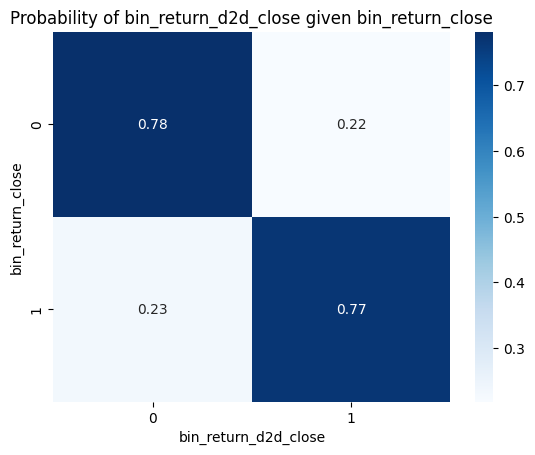

In [47]:
probs = pd.crosstab(
    y_train['bin_return_close'],
    y_train['bin_return_d2d_close'],
    normalize='index'
)
overall_prob = (y_train['bin_return_close'] == y_train['bin_return_d2d_close']).mean()
print("Overall probability of bin_return_d2d_close being the same as bin_return_close:\n{:.3f}".format(overall_prob))
sns.heatmap(probs, annot=True, fmt=".2f", cmap="Blues")
plt.title("Probability of bin_return_d2d_close given bin_return_close")
plt.xlabel("bin_return_d2d_close")
plt.ylabel("bin_return_close")
plt.show()

In [48]:
def generate_lags(X, y, lags_num, output_value, feature_scaler=None, target_scaler=None, fit_scalers=False):
    X_values = X['log_return_close'].values.reshape(-1, 1)
    y_values = y[output_value].values.reshape(-1, 1)

    if feature_scaler is not None:
        X_values = feature_scaler.fit_transform(X_values) if fit_scalers else feature_scaler.transform(X_values)
    if target_scaler is not None and not BINARY_CLASSIFICATION:
        y_values = target_scaler.fit_transform(y_values) if fit_scalers else target_scaler.transform(y_values)

    X_values = X_values.flatten()
    y_values = y_values.flatten()
    X_return = []
    y_return = []

    for i in range(lags_num, len(X_values)):
        X_return.append(X_values[i-lags_num:i])
        y_return.append(y_values[i])

    return np.array(X_return), np.array(y_return)


In [49]:
feature_scaler = StandardScaler() if SCALER_BOOLEAN else None
target_scaler = StandardScaler() if SCALER_BOOLEAN and not BINARY_CLASSIFICATION else None

X_train, y_train = generate_lags(X_train, y_train, LAGS_NUM, OUTPUT_VALUE, feature_scaler, target_scaler, fit_scalers=True)
X_val, y_val = generate_lags(X_val, y_val, LAGS_NUM, OUTPUT_VALUE, feature_scaler, target_scaler)
X_test, y_test = generate_lags(X_test, y_test, LAGS_NUM, OUTPUT_VALUE, feature_scaler, target_scaler)


## Building and training model

In [50]:
common_params = {
    'n_estimators': N_ESTIMATORS,
    'max_depth': MAX_DEPTH,
    'learning_rate': LEARNING_RATE,
    'subsample': SUBSAMPLE,
    'colsample_bytree': COLSAMPLE_BYTREE,
    'random_state': RANDOM_STATE,
    'tree_method': 'hist',
}

if BINARY_CLASSIFICATION:
    model = XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        **common_params,
    )
else:
    model = XGBRegressor(
        objective='reg:squarederror',
        eval_metric='mae',
        **common_params,
    )

print(model)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)


In [51]:
def fit_xgboost_model(model, X_train, y_train, X_val, y_val, early_stopping_rounds):
    fit_kwargs = {
        'eval_set': [(X_val, y_val)],
        'verbose': False,
    }

    try:
        model.fit(X_train, y_train, early_stopping_rounds=early_stopping_rounds, **fit_kwargs)
    except TypeError:
        try:
            from xgboost.callback import EarlyStopping
            model.fit(
                X_train,
                y_train,
                callbacks=[EarlyStopping(rounds=early_stopping_rounds, save_best=True)],
                **fit_kwargs,
            )
        except (TypeError, ImportError):
            model.fit(X_train, y_train, **fit_kwargs)

    return model

print("Binary classification" if BINARY_CLASSIFICATION else "Regression")
model = fit_xgboost_model(model, X_train, y_train, X_val, y_val, PATIENCE_NUM)


Binary classification


## Verifying model

In [52]:
y_pred = model.predict(X_test)

if not BINARY_CLASSIFICATION and target_scaler is not None:
    y_pred = target_scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()
    y_test = target_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()


In [53]:
print(y_test[:10])
print(y_pred[:10])


[1 1 0 0 1 0 0 1 0 1]
[1 0 0 0 1 0 1 1 0 0]


In [54]:
if BINARY_CLASSIFICATION:
    print(classification_report(y_test, y_pred, digits=4))
else:
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    directional_accuracy = np.mean((y_pred > 0) == (y_test > 0))
    print(f"MAE: {mae:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"Directional accuracy: {directional_accuracy:.4f}")


              precision    recall  f1-score   support

           0     0.7455    0.7300    0.7377      1485
           1     0.7274    0.7431    0.7351      1440

    accuracy                         0.7364      2925
   macro avg     0.7365    0.7365    0.7364      2925
weighted avg     0.7366    0.7364    0.7364      2925



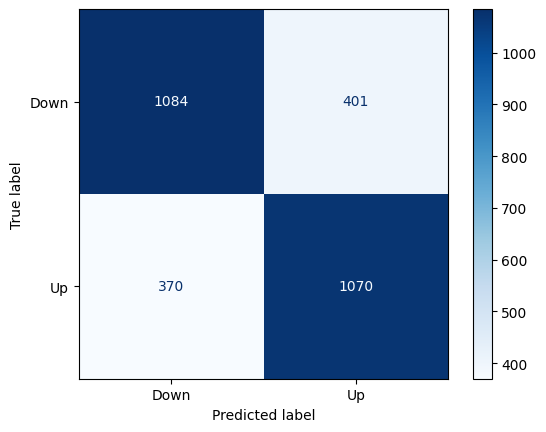

In [55]:
if BINARY_CLASSIFICATION:
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues', display_labels=["Down", "Up"])
else:
    print("Confusion matrix is not applicable for regression.")
    plt.figure(figsize=(12, 8))
    plt.plot(y_test, label='True')
    plt.plot(y_pred, label='Predicted')
    plt.legend()
    plt.show()


In [56]:
if BINARY_CLASSIFICATION:
    prob_coverage = overall_prob * classification_report(y_test, y_pred, output_dict=True)['accuracy']
    print("Coverage model accuracy based on bin_return_close:\n{:.3f}".format(prob_coverage))
else:
    print("Coverage model accuracy based on bin_return_close is only defined for classification.")


Coverage model accuracy based on bin_return_close:
0.570


## Backtesting model

Final cash: 1950.00
Total return: 95.00%
Price direction bet accuracy: 0.5162
Strategy annualized Sharpe (risk-free=0.0%): 3.2148
Buy and hold return: -25.25%
Buy and hold annualized Sharpe: -1.5082


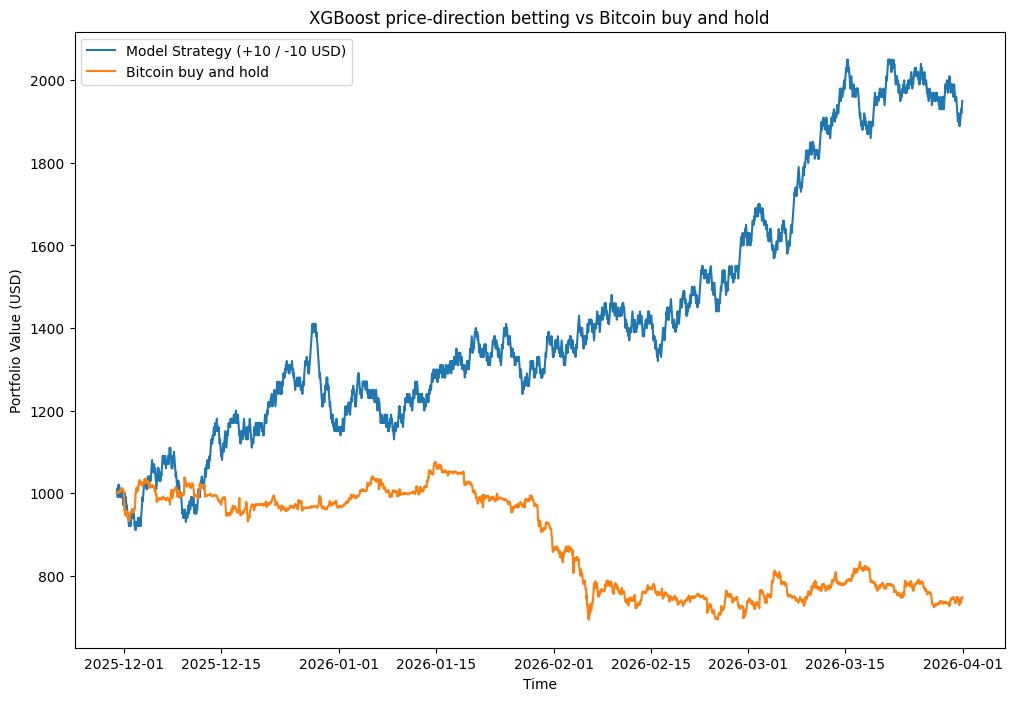

In [57]:
# Match the requested strategy: interpret predicted class 1 as UP and 0 as DOWN.
# For bin_return_d2d_close, price-direction
# betting accuracy below is therefore a different metric from its report.
# Predictions correspond to the test block after its first LAGS_NUM rows.
predictions = np.asarray(y_pred).ravel()
backtest_index = X_backtest.index[LAGS_NUM:]
if len(predictions) == 0 or len(predictions) != len(backtest_index):
    raise ValueError("Predictions must match the test samples after lag generation.")
if not np.isfinite(predictions).all():
    raise ValueError("Predictions contain non-finite values.")
if BINARY_CLASSIFICATION and not np.isin(predictions, [0, 1]).all():
    raise ValueError("Classification predictions must be labels 0 or 1.")
y_return = X_backtest.loc[backtest_index, 'return_close'].to_numpy()
signal = predictions.astype(int) if BINARY_CLASSIFICATION else (predictions > 0).astype(int)
START_CASH = 1000.0
BET_PAYOUT = 10.0
start_cash = START_CASH
cash = start_cash
movement_list = [cash]
for prediction, actual_return in zip(signal, y_return):
    if prediction == 1:
        cash += BET_PAYOUT if actual_return > 0 else -BET_PAYOUT
    else:
        cash += BET_PAYOUT if actual_return < 0 else -BET_PAYOUT
    movement_list.append(cash)
# As in the supplied example, zero price change loses for either direction.
# This fixed-stake simulation continues even if capital reaches zero.

settlement_index = backtest_index + pd.Timedelta(milliseconds=TIMEFRAME_DICT[TIMEFRAME])
curve_index = pd.DatetimeIndex([backtest_index[0]]).append(settlement_index)
strategy_curve = pd.Series(movement_list, index=curve_index, name="Model Strategy")
# Compound actual simple returns: cumsum is only an approximation to buy and hold.
buy_and_hold_curve = pd.Series(
    np.r_[start_cash, start_cash * np.cumprod(1 + y_return)],
    index=curve_index, name="Bitcoin buy and hold")

RISK_FREE_ANNUAL = 0.0
# Crypto trades 24/7: 8760 hourly periods per 365-day year.
periods_per_year = (365 * 24 * 60 * 60 * 1000) / TIMEFRAME_DICT[TIMEFRAME]

def annualized_sharpe(equity, periods_per_year, risk_free_annual=0.0):
    equity = np.asarray(equity, dtype=float)
    if (len(equity) < 3 or not np.isfinite(equity).all()
            or (equity <= 0).any()):
        return np.nan  # Percentage-return Sharpe is not reported after insolvency.
    returns = np.diff(equity) / equity[:-1]
    risk_free_per_period = np.expm1(np.log1p(risk_free_annual) / periods_per_year)
    excess_returns = returns - risk_free_per_period
    volatility = excess_returns.std(ddof=1)
    if np.isclose(volatility, 0.0):
        return np.nan
    # Conventional square-root annualization; not adjusted for autocorrelation.
    return np.sqrt(periods_per_year) * excess_returns.mean() / volatility

strategy_sharpe = annualized_sharpe(strategy_curve, periods_per_year, RISK_FREE_ANNUAL)
buy_and_hold_sharpe = annualized_sharpe(buy_and_hold_curve, periods_per_year, RISK_FREE_ANNUAL)
backtest_results = pd.DataFrame({
    "prediction": predictions,
    "predicted_direction": signal,
}, index=backtest_index)
backtest_results["price_return"] = y_return
backtest_results["pnl_usd"] = np.diff(movement_list)
backtest_results["cash"] = movement_list[1:]

print(f"Final cash: {cash:.2f}")
print(f"Total return: {(cash - start_cash) / start_cash * 100:.2f}%")
print(f"Price direction bet accuracy: {(backtest_results.pnl_usd > 0).mean():.4f}")
print(f"Strategy annualized Sharpe (risk-free={RISK_FREE_ANNUAL:.1%}): {strategy_sharpe:.4f}")
print(f"Buy and hold return: {(buy_and_hold_curve.iloc[-1] / start_cash - 1) * 100:.2f}%")
print(f"Buy and hold annualized Sharpe: {buy_and_hold_sharpe:.4f}")
if (strategy_curve <= 0).any():
    print("Strategy reached non-positive capital: Sharpe is undefined (NaN).")
plt.figure(figsize=(12, 8))
plt.plot(strategy_curve.index, strategy_curve, label="Model Strategy (+10 / -10 USD)")
plt.plot(buy_and_hold_curve.index, buy_and_hold_curve, label="Bitcoin buy and hold")
plt.xlabel("Time")
plt.ylabel("Portfolio Value (USD)")
plt.title("XGBoost price-direction betting vs Bitcoin buy and hold")
plt.legend()
plt.show()